# Data Exploration

This notebook was used to explore some of the data available on the FastF1 API.

The first four plots are examples from the FastF1 visualisation strategy.

In [2]:
# Imports
import fastf1
from fastf1 import plotting
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

core           INFO 	Loading data for Chinese Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['81', '4', '63', '1', '31', '12', '23', '87', '18', '55', '6', '30', '7', '5', '27', '22', '14', '16', '44', '10']
core           INFO 	Loading data for Chinese Grand Prix - Race

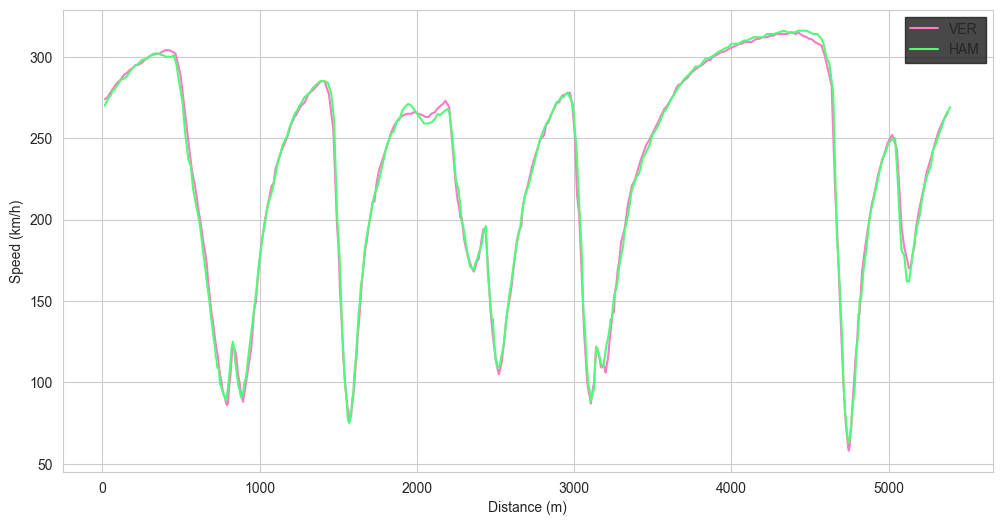

In [16]:
fastf1.Cache.enable_cache('../data/cacheF1')

race = fastf1.get_session(2025, "Chinese", 'R')
race.load()

quali = fastf1.get_session(2025, "Chinese", 'R')
quali.load()

# Get the fastest lap for each driver in Q3
q3_results = []
for driver in quali.drivers:
    try:
        fastest = quali.laps.pick_drivers(driver).pick_fastest()
        q3_results.append({
            'Driver': driver,
            'LapTime': fastest['LapTime'],
            'Team': fastest['Team']
        })
    except:
        pass  # Driver didn't set a lap

q3_df = pd.DataFrame(q3_results).sort_values('LapTime')

# Compare speed traces for two drivers
ver_lap = quali.laps.pick_drivers('VER').pick_fastest()
ham_lap = quali.laps.pick_drivers('HAM').pick_fastest()

# Get telemetry data
ver_tel = ver_lap.get_car_data().add_distance()
ham_tel = ham_lap.get_car_data().add_distance()

# Plot speed comparison
fig, ax = plt.subplots()
ax.plot(ver_tel['Distance'], ver_tel['Speed'], label='VER')
ax.plot(ham_tel['Distance'], ham_tel['Speed'], label='HAM')
ax.set_xlabel('Distance (m)')
ax.set_ylabel('Speed (km/h)')
ax.legend()
plt.show()


Stint Analysis:   Stint                LapTime                         \
                         first                   last   
0   1.0 0 days 00:01:39.268000 0 days 00:01:38.389000   
1   2.0 0 days 00:01:37.432000 0 days 00:01:39.418000   

                                  Compound  
                       mean count    first  
0 0 days 00:01:38.172428571    14   MEDIUM  
1    0 days 00:01:36.785850    40     HARD  
Stint 1.0: 0.017s/lap degradation


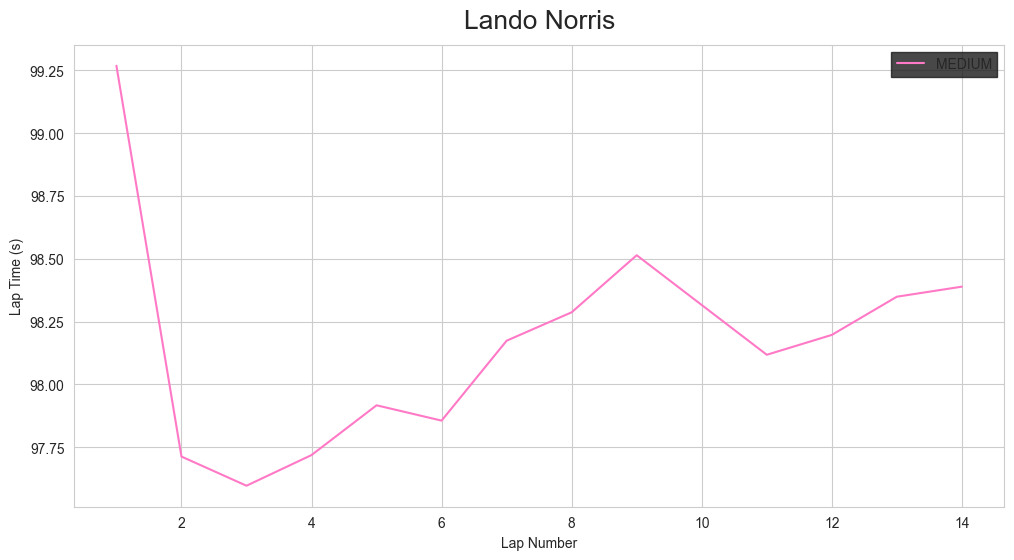

Stint 2.0: -0.023s/lap degradation


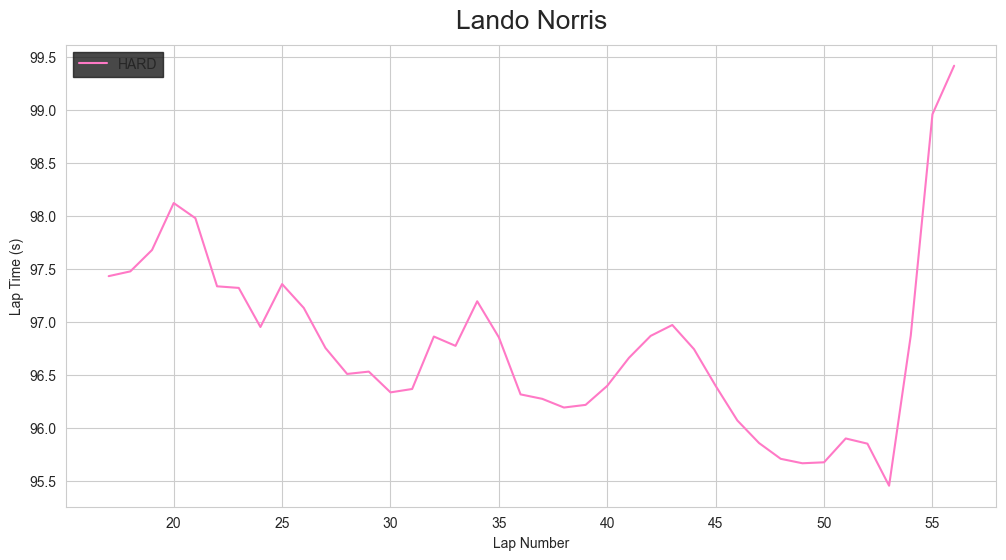

In [15]:
# Analyse stint performance
driver_laps = race.laps.pick_drivers('NOR').pick_quicklaps()

# Group by stint and calculate degradation
stint_analysis = driver_laps.groupby('Stint').agg({
    'LapTime': ['first', 'last', 'mean', 'count'],
    'Compound': 'first'
}).reset_index()

print(f"Stint Analysis: {stint_analysis}")

# Calculate tire degradation per stint
for stint in driver_laps['Stint'].unique():
    stint_laps = driver_laps[driver_laps['Stint'] == stint]

    # Convert lap times to seconds for regression
    lap_numbers = stint_laps['LapNumber'].values
    lap_times = stint_laps['LapTime'].dt.total_seconds().values

    # Linear regression to estimate degradation
    from numpy.polynomial import Polynomial

    p = Polynomial.fit(lap_numbers, lap_times, 1)
    degradation_per_lap = p.convert().coef[1]

    print(f"Stint {stint}: {degradation_per_lap:.3f}s/lap degradation")

    fig, ax = plt.subplots()
    ax.set_title('Lando Norris')
    ax.plot(lap_numbers, lap_times, label=stint_analysis['Compound'].iloc[int(stint)-1])
    ax.set_xlabel('Lap Number')
    ax.set_ylabel('Lap Time (s)')
    ax.legend()
    plt.show()

core           INFO 	Loading data for Chinese Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['81', '4', '63', '1', '31', '12', '23', '87', '18', '55', '6', '30', '7', '5', '27', '22', '14', '16', '44', '10']


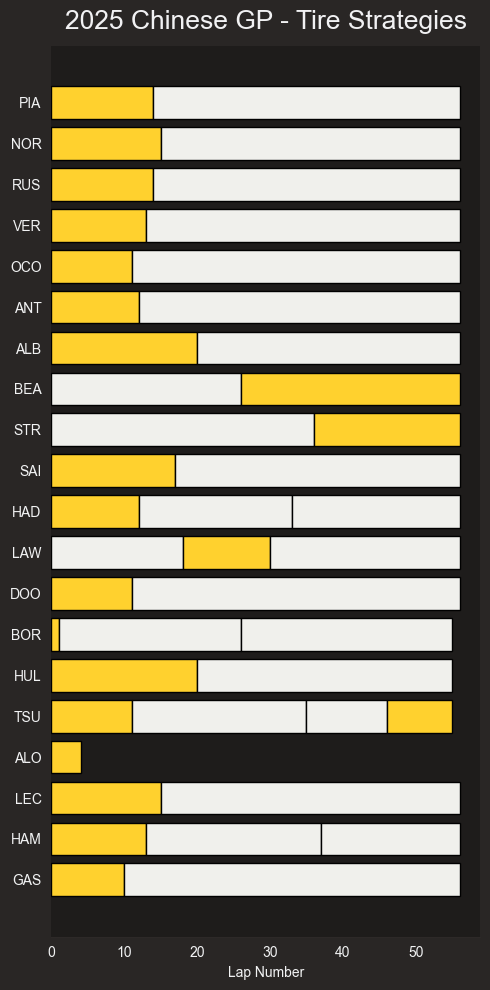

In [5]:
plotting.setup_mpl(color_scheme='fastf1')

session = fastf1.get_session(2025, "Chinese", 'R')
session.load()
laps = session.laps

# Get drivers and convert to abbreviations
drivers = [session.get_driver(d)["Abbreviation"] for d in session.drivers]

# Group laps by driver, stint, and compound
stints = laps[["Driver", "Stint", "Compound", "LapNumber"]]
stints = stints.groupby(["Driver", "Stint", "Compound"]).count().reset_index()
stints = stints.rename(columns={"LapNumber": "StintLength"})

# Plot strategies
fig, ax = plt.subplots(figsize=(5, 10))

for driver in drivers:
    driver_stints = stints.loc[stints["Driver"] == driver]

    previous_stint_end = 0
    for idx, row in driver_stints.iterrows():
        compound_color = plotting.get_compound_color(
            row["Compound"],
            session=session
        )
        plt.barh(
            y=driver,
            width=row["StintLength"],
            left=previous_stint_end,
            color=compound_color,
            edgecolor="black",
            fill=True
        )
        previous_stint_end += row["StintLength"]

plt.title("2025 Chinese GP - Tire Strategies")
plt.xlabel("Lap Number")
plt.grid(False)
ax.invert_yaxis()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
plt.tight_layout()
plt.show()

In [6]:
# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Load data
data_path = Path('../data/raw/Australian Grand Prix/2022/03_Australian_Grand_Prix_R_laps.csv')
laps = pd.read_csv(data_path)

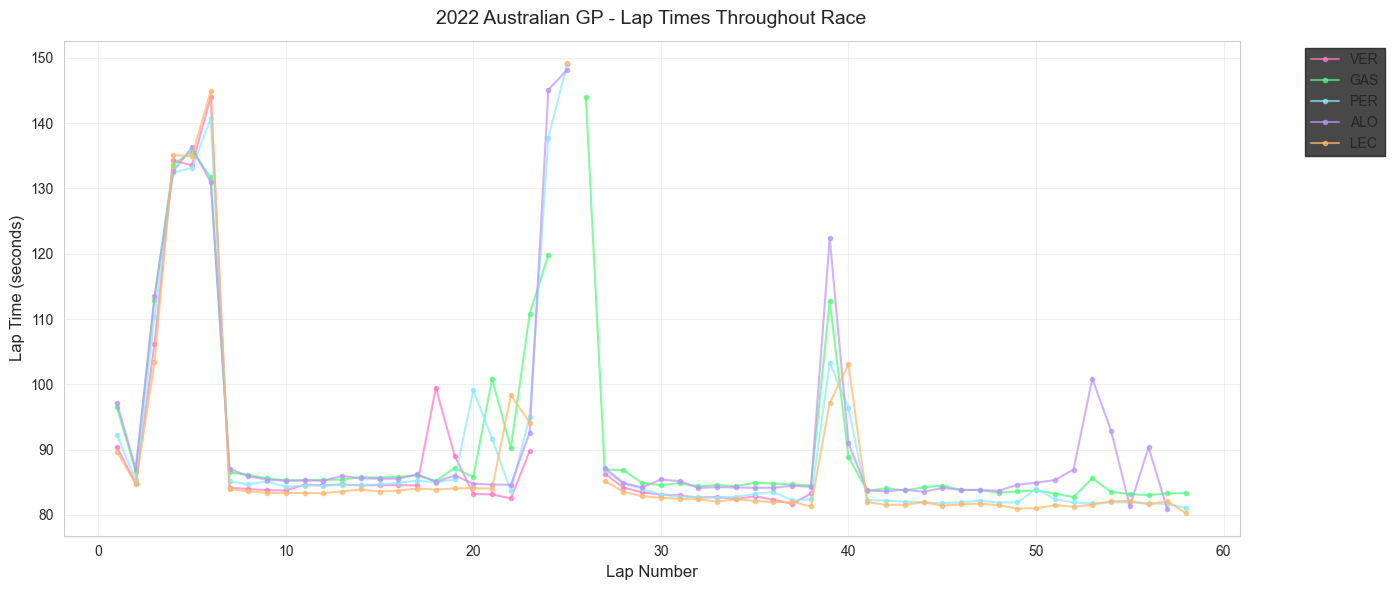

In [7]:
# Lap times over the race
fig, ax = plt.subplots(figsize=(14, 6))

# Plot each driver's lap times
for driver in laps['Driver'].unique()[:5]:  # First 5 drivers
    driver_laps = laps[laps['Driver'] == driver].copy()

    # Convert lap time to seconds
    driver_laps['LapTimeSeconds'] = pd.to_timedelta(
        driver_laps['LapTime']
    ).dt.total_seconds()

    ax.plot(driver_laps['LapNumber'],
            driver_laps['LapTimeSeconds'],
            marker='o',
            markersize=3,
            label=driver,
            alpha=0.7)

ax.set_xlabel('Lap Number', fontsize=12)
ax.set_ylabel('Lap Time (seconds)', fontsize=12)
ax.set_title('2022 Australian GP - Lap Times Throughout Race', fontsize=14)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/figures/lap_times.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# Pit stop analysis
# Identify pit laps (where lap time suddenly jumps)
laps_sorted = laps.sort_values(['Driver', 'LapNumber'])

# Pit stop detection:
laps_sorted['IsPitLap'] = laps_sorted['PitInTime'].notna().astype(int) # .notna() checks the row if It's empty or not
pit_stops = laps_sorted[laps_sorted['IsPitLap'] == 1].groupby('Driver').size()

print("\nPit stops per driver:")
print(pit_stops.sort_values(ascending=False))


Pit stops per driver:
Driver
STR    3
LAT    2
ALO    2
ALB    1
OCO    1
VER    1
TSU    1
RUS    1
RIC    1
PER    1
NOR    1
MSC    1
MAG    1
LEC    1
HAM    1
GAS    1
BOT    1
ZHO    1
dtype: int64


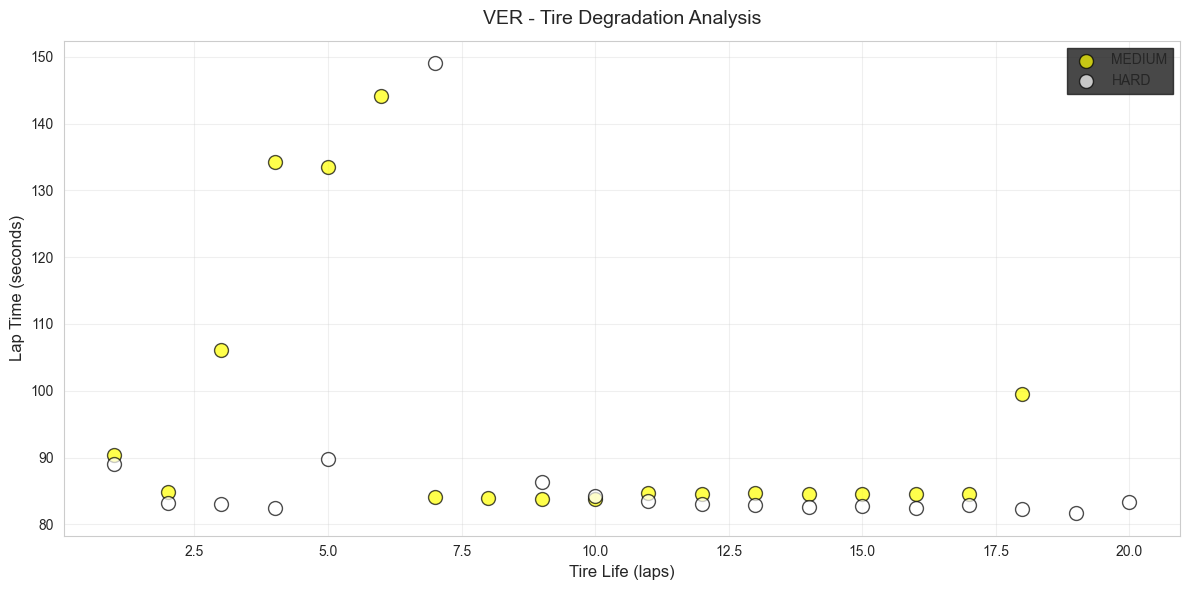

In [14]:
# Tire degradation visualisation
fig, ax = plt.subplots(figsize=(12, 6))

# Pick a driver (e.g., VER for Verstappen)
driver = 'VER'
driver_laps = laps[laps['Driver'] == driver].copy()
driver_laps['LapTimeSeconds'] = pd.to_timedelta(
    driver_laps['LapTime']
).dt.total_seconds()

# Colour by tire compound
colors = {'SOFT': 'red', 'MEDIUM': 'yellow', 'HARD': 'white'}

for compound in driver_laps['Compound'].unique():
    compound_laps = driver_laps[driver_laps['Compound'] == compound]
    ax.scatter(compound_laps['TyreLife'],
               compound_laps['LapTimeSeconds'],
               c=colors.get(compound, 'white'),
               edgecolors='black',
               s=100,
               label=compound,
               alpha=0.7)

ax.set_xlabel('Tire Life (laps)', fontsize=12)
ax.set_ylabel('Lap Time (seconds)', fontsize=12)
ax.set_title(f'{driver} - Tire Degradation Analysis', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'../data/figures/{driver}_tire_degradation.png', dpi=150, bbox_inches='tight')
plt.show()